### INITIAL TURBULENCE-STATE STATISTICS AFTER MITgcm SPIN-UP
## Metrics:
###   - EKE
###   - Dissipation rate
###   - MLD from GLORYS
###   - bulk Richardson number


In [5]:
from pathlib import Path
import sys
import json
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

NB_DIR = Path.cwd()

# This notebook is in: z_flow_postprocessing/notebooks
# ocean_analysis.py is in: OGCM/scripts
OGCM_DIR = NB_DIR.parents[1] / "OGCM"
PROJECT_DIR = OGCM_DIR.parent

for p in [
    OGCM_DIR / "scripts",
    PROJECT_DIR,          # needed for theme.plot_theme
]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import theme.plot_theme as ptheme
import ocean_analysis as oa

ptheme.apply_theme()

print("Notebook dir:", NB_DIR)
print("OGCM dir     :", OGCM_DIR)
print("Imported oa  :", oa.__file__)

Notebook dir: c:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\notebooks
OGCM dir     : c:\Users\Jelle Gortemaker\Documents\Thesis\OGCM
Imported oa  : c:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py


Opening MITgcm file:
C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\data\input\run_feb1_1000m.nc

Opening GLORYS file:
C:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\data\input\GPGP_feb2020_3D_37.0_40.0_147.76_144.24.nc

Selected MITgcm post-spinup snapshot:
  selected index : 0
  T[0]         : 852760
  T units        : s

Selected GLORYS MLD snapshot:
  selected index : 0
  time[0]      : 2020-02-01

Variables used:
  U velocity  : UVEL
  V velocity  : VVEL
  temperature : THETA
  salinity    : SALT

MITgcm field shapes after centering/cropping:
  U centered : (61, 256, 256)
  V centered : (61, 256, 256)
  Temp       : (61, 256, 256)
  S          : (61, 256, 256)
  Z levels   : 61
  depth range: 1.00 to 61.00 m

QUALITY CHECKS: RAW POST-SPINUP FIELDS

QC: surface U
  shape              : (256, 256)
  finite fraction    : 1.0000
   min              : -3.963868e-01 m/s
   p01              : -2.311585e-01 m/s
   p05              : -1.469287e-01 m/s
   p25             

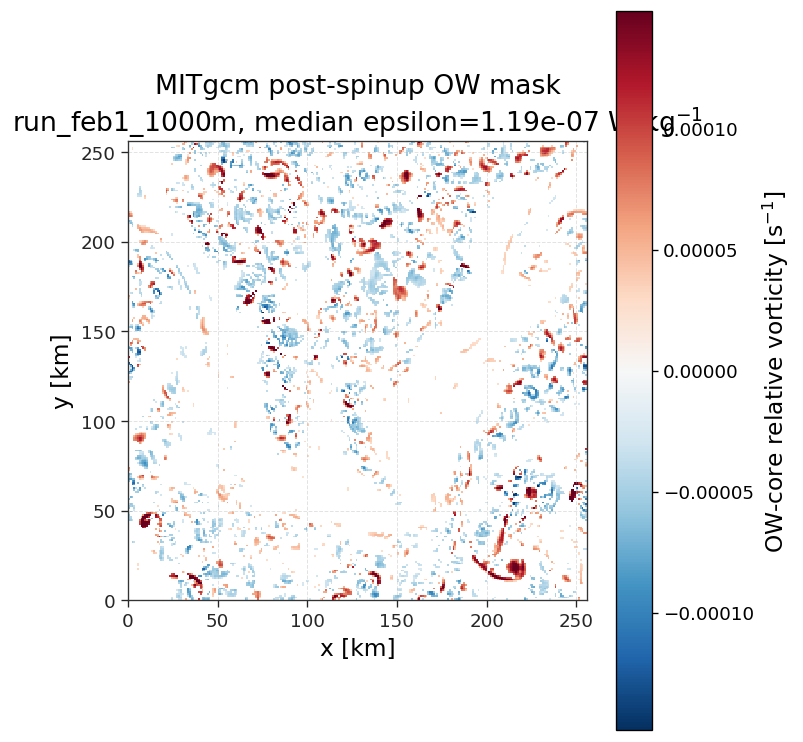

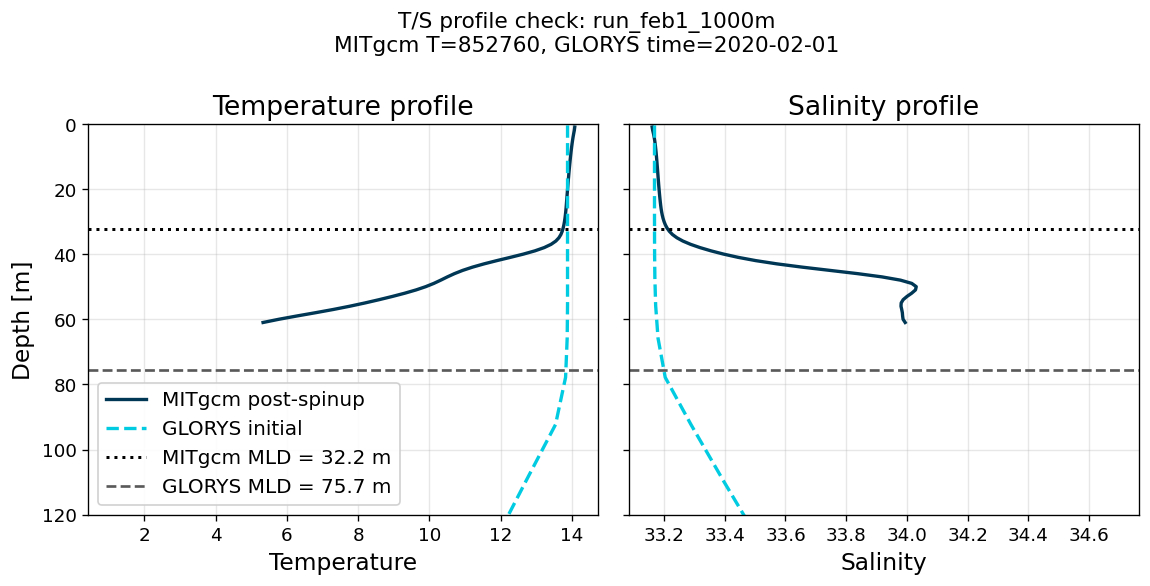

Saved sigma-theta profile check:
C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_feb1_1000m\run_feb1_1000m_sigma_theta_profile_MLD_check.png


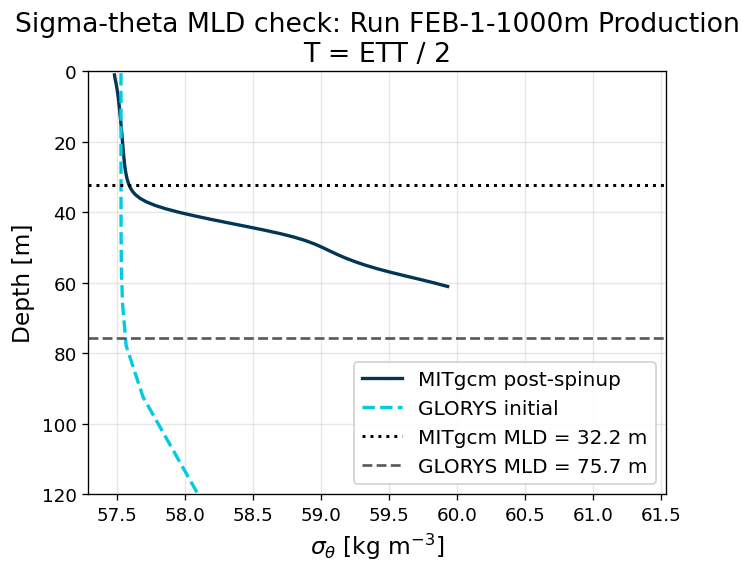


4. LOCAL BULK RICHARDSON NUMBER
  definition            : g*Delta(rho)*Delta(z) / [rho0*((Delta u)^2 + (Delta v)^2)]
  reference depth       : 10.00 m
  target depth          : local MITgcm sigma-theta MLD
  Ri_b mean             : 1.569240e+02
  Ri_b median           : 1.123915e+01

QC: local Ri_b components

QC: local MLD
  shape              : (256, 256)
  finite fraction    : 1.0000
   min              : 1.187183e+01 m
   p01              : 1.341127e+01 m
   p05              : 1.605952e+01 m
   p25              : 2.792396e+01 m
   p50              : 3.224539e+01 m
   p75              : 3.468179e+01 m
   p95              : 3.698305e+01 m
   p99              : 3.810664e+01 m
   max              : 4.012575e+01 m

QC: Delta z
  shape              : (256, 256)
  finite fraction    : 1.0000
   min              : 1.871833e+00 m
   p01              : 3.411268e+00 m
   p05              : 6.059522e+00 m
   p25              : 1.792396e+01 m
   p50              : 2.224539e+01 m
   p75        

In [6]:
# ============================================================
# SETTINGS
# ============================================================

case_name = "run_feb1_1000m"                         # edit
glorys_case = "GPGP_feb2020_3D_37.0_40.0_147.76_144.24"      # edit
RUN_TITLE_INFO = "Run FEB-1-1000m Production"                                 # edit

MITGCM_FILE = (NB_DIR / f"../data/input/{case_name}.nc").resolve()
GLORYS_FILE = (NB_DIR / f"../../OGCM/data/input/{glorys_case}.nc").resolve()

# Time indices
MITGCM_TIME_INDEX = 0
GLORYS_TIME_INDEX = 0

# OW / ETT settings
OW_ALPHA = 0.2
OW_MIN_CELLS = 8
OW_SEARCH_RADIUS_FACTOR = 1.25

# OW quality filters
MIN_RMAX_CELLS = 3.0
BOUNDARY_FACTOR = 1.0
MIN_UTHETA_M_S = 1e-6
MAX_RMAX_FRACTION_DOMAIN = 0.20

# MLD criterion
MLD_DELTA_SIGMA = 0.06
MLD_REFERENCE_DEPTH_M = 10.0

# Linear EOS constants
RHO0 = 1035.0
ALPHA_T = 2.0e-4
BETA_S = 7.4e-4
G = 9.81

# Minimum shear to avoid infinite Richardson numbers
MIN_DELTA_U2 = 1e-10

# Output
OUT_DIR = (NB_DIR / f"../results/{case_name}").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_ATTRS_FILE = OUT_DIR / f"{case_name}_domain_characterization.json"
OUT_OW_TABLE_FILE = OUT_DIR / f"{case_name}_mitgcm_ow_eddy_table.csv"
OUT_OW_MAP_FILE = OUT_DIR / f"{case_name}_mitgcm_ow_map.png"
OUT_OW_PROFILE_FILE = OUT_DIR / f"{case_name}_mitgcm_ow_profiles.png"
OUT_TS_PROFILE_FILE = OUT_DIR / f"{case_name}_TS_profile_MLD_check.png"
OUT_SIGMA_PROFILE_FILE = OUT_DIR / f"{case_name}_sigma_theta_profile_MLD_check.png"


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def center_u_to_tracer(u):
    """Center MITgcm U from Xp1 to X. Shape: (Z, Y, Xp1) -> (Z, Y, X)."""
    return 0.5 * (u[:, :, :-1] + u[:, :, 1:])


def center_v_to_tracer(v):
    """Center MITgcm V from Yp1 to Y. Shape: (Z, Yp1, X) -> (Z, Y, X)."""
    return 0.5 * (v[:, :-1, :] + v[:, 1:, :])


def crop_to_common(*arrays):
    """Crop arrays to common trailing horizontal shape."""
    ny = min(a.shape[-2] for a in arrays)
    nx = min(a.shape[-1] for a in arrays)
    return tuple(a[..., :ny, :nx] for a in arrays)


def positive_down_mitgcm_depth(ds):
    """Return positive-down MITgcm vertical coordinate from Z or diag_levels."""
    if "Z" in ds.coords:
        z = np.asarray(ds["Z"].values, dtype=float)
    elif "diag_levels" in ds.variables:
        z = np.asarray(ds["diag_levels"].values, dtype=float)
    else:
        raise KeyError("Could not find MITgcm vertical coordinate: expected 'Z' or 'diag_levels'.")

    if np.nanmean(z) < 0:
        z = -z

    return z


def positive_down_glorys_depth(ds_glorys):
    """Return positive-down GLORYS depth coordinate."""
    z = np.asarray(ds_glorys["depth"].values, dtype=float)
    if np.nanmean(z) < 0:
        z = -z
    return z


def interp_3d_to_depth(field_zyx, z_m, target_depth_m):
    """Interpolate a 3D field (Z, Y, X) to a scalar positive-down depth."""
    field_zyx = np.asarray(field_zyx, dtype=float)
    z_m = np.asarray(z_m, dtype=float)

    if target_depth_m <= z_m[0]:
        return field_zyx[0, :, :]

    if target_depth_m >= z_m[-1]:
        return field_zyx[-1, :, :]

    k2 = int(np.searchsorted(z_m, target_depth_m))
    k1 = k2 - 1

    z1, z2 = z_m[k1], z_m[k2]
    w = (target_depth_m - z1) / (z2 - z1)

    return (1.0 - w) * field_zyx[k1, :, :] + w * field_zyx[k2, :, :]



def interp_3d_to_depth_field(field_zyx, z_m, target_depth_yx):
    """
    Interpolate a 3D field (Z, Y, X) to a local depth field (Y, X).

    Parameters
    ----------
    field_zyx : array-like
        Field on vertical levels, shape (Z, Y, X).
    z_m : array-like
        Positive-down vertical coordinate, shape (Z,).
    target_depth_yx : array-like
        Positive-down target depth at each horizontal grid point, shape (Y, X).
    """
    field_zyx = np.asarray(field_zyx, dtype=float)
    z_m = np.asarray(z_m, dtype=float)
    target_depth_yx = np.asarray(target_depth_yx, dtype=float)

    if field_zyx.ndim != 3:
        raise ValueError("field_zyx must have shape (Z, Y, X).")
    if target_depth_yx.shape != field_zyx.shape[1:]:
        raise ValueError(
            f"target_depth_yx shape {target_depth_yx.shape} does not match "
            f"field horizontal shape {field_zyx.shape[1:]}."
        )

    out = np.full(target_depth_yx.shape, np.nan, dtype=float)

    finite_target = np.isfinite(target_depth_yx)
    shallow = finite_target & (target_depth_yx <= z_m[0])
    deep = finite_target & (target_depth_yx >= z_m[-1])

    out[shallow] = field_zyx[0][shallow]
    out[deep] = field_zyx[-1][deep]

    interior = finite_target & ~shallow & ~deep

    for k in range(len(z_m) - 1):
        mask = interior & (target_depth_yx >= z_m[k]) & (target_depth_yx < z_m[k + 1])
        if not np.any(mask):
            continue

        w = (target_depth_yx[mask] - z_m[k]) / (z_m[k + 1] - z_m[k])
        f1 = field_zyx[k][mask]
        f2 = field_zyx[k + 1][mask]
        out[mask] = (1.0 - w) * f1 + w * f2

    return out


def density_linear(temp, salt):
    """Linear EOS used for density differences."""
    return RHO0 * (1.0 - ALPHA_T * temp + BETA_S * salt)


def sigma_theta_linear(temp, salt):
    """Approximate sigma_theta = rho_theta - 1000 using the same linear EOS."""
    return density_linear(temp, salt) - 1000.0


def interp_profile_1d(z, q, z_target):
    """Interpolate one vertical profile q(z) to z_target."""
    z = np.asarray(z, dtype=float)
    q = np.asarray(q, dtype=float)

    valid = np.isfinite(z) & np.isfinite(q)

    if np.count_nonzero(valid) < 2:
        return np.nan

    z_valid = z[valid]
    q_valid = q[valid]

    if z_target <= z_valid[0]:
        return float(q_valid[0])

    if z_target >= z_valid[-1]:
        return float(q_valid[-1])

    return float(np.interp(z_target, z_valid, q_valid))


def calculate_mld_sigma_theta(
    temp_zyx,
    salt_zyx,
    z_m,
    delta_sigma=0.03,
    reference_depth_m=10.0,
):
    """
    Calculate MLD from sigma_theta threshold criterion:

        MLD = first depth where
        sigma_theta(z) >= sigma_theta(reference_depth) + delta_sigma
    """
    temp_zyx = np.asarray(temp_zyx, dtype=float)
    salt_zyx = np.asarray(salt_zyx, dtype=float)
    z_m = np.asarray(z_m, dtype=float)

    sigma = sigma_theta_linear(temp_zyx, salt_zyx)

    nz, ny, nx = sigma.shape
    mld_field = np.full((ny, nx), np.nan)

    for j in range(ny):
        for i in range(nx):
            prof = sigma[:, j, i]

            if np.count_nonzero(np.isfinite(prof)) < 2:
                continue

            sigma_ref = interp_profile_1d(z_m, prof, reference_depth_m)

            if not np.isfinite(sigma_ref):
                continue

            threshold = sigma_ref + delta_sigma
            deeper = np.where(prof >= threshold)[0]

            if len(deeper) == 0:
                mld_field[j, i] = z_m[-1]
                continue

            k = int(deeper[0])

            if k == 0:
                mld_field[j, i] = z_m[0]
                continue

            z1, z2 = z_m[k - 1], z_m[k]
            s1, s2 = prof[k - 1], prof[k]

            if not np.isfinite(s1) or not np.isfinite(s2) or s2 == s1:
                mld_field[j, i] = z2
            else:
                w = (threshold - s1) / (s2 - s1)
                mld_field[j, i] = z1 + w * (z2 - z1)

    return mld_field, sigma


def find_mld_from_profile_sigma(
    sigma_profile,
    z_m,
    delta_sigma=0.03,
    reference_depth_m=10.0,
):
    """1D profile-based MLD from sigma-theta threshold."""
    sigma_profile = np.asarray(sigma_profile, dtype=float)
    z_m = np.asarray(z_m, dtype=float)

    sigma_ref = interp_profile_1d(z_m, sigma_profile, reference_depth_m)
    threshold = sigma_ref + delta_sigma

    deeper = np.where(sigma_profile >= threshold)[0]

    if len(deeper) == 0:
        return float(z_m[-1]), float(sigma_ref), float(threshold)

    k = int(deeper[0])

    if k == 0:
        return float(z_m[0]), float(sigma_ref), float(threshold)

    z1, z2 = z_m[k - 1], z_m[k]
    s1, s2 = sigma_profile[k - 1], sigma_profile[k]

    if not np.isfinite(s1) or not np.isfinite(s2) or s2 == s1:
        return float(z2), float(sigma_ref), float(threshold)

    w = (threshold - s1) / (s2 - s1)
    mld = z1 + w * (z2 - z1)

    return float(mld), float(sigma_ref), float(threshold)


def get_time_value(ds, dim_name, index):
    """Return raw coordinate value and printable string for a time coordinate."""
    value = ds[dim_name].isel({dim_name: index}).values

    if np.issubdtype(np.asarray(value).dtype, np.datetime64):
        value_str = np.datetime_as_string(value, unit="D")
        value_raw = value_str
    else:
        value_raw = float(np.asarray(value))
        value_str = f"{value_raw:g}"

    return value_raw, value_str


def finite_fraction(a):
    a = np.asarray(a)
    return np.isfinite(a).sum() / a.size


def print_field_qc(name, a, units=""):
    """Print finite fraction and percentiles."""
    a = np.asarray(a, dtype=float)
    finite = a[np.isfinite(a)]

    print(f"\nQC: {name}")
    print(f"  shape              : {a.shape}")
    print(f"  finite fraction    : {finite_fraction(a):.4f}")

    if finite.size == 0:
        print("  WARNING: no finite values")
        return

    p = np.nanpercentile(finite, [0, 1, 5, 25, 50, 75, 95, 99, 100])
    labels = ["min", "p01", "p05", "p25", "p50", "p75", "p95", "p99", "max"]

    for lab, val in zip(labels, p):
        print(f"  {lab:>4s}              : {val:.6e} {units}")


def print_fraction_check(name, condition):
    condition = np.asarray(condition)
    frac = np.nanmean(condition)
    print(f"  fraction {name:<35s}: {frac:.4f}")


def horizontal_mean_profile(field_zyx):
    """Compute horizontal mean profile of a 3D field with shape (Z, Y, X)."""
    return np.nanmean(field_zyx, axis=(-2, -1))


def print_profile_mld_check(name, z_m, profile, mld_m):
    """Print profile values at surface and MLD."""
    profile = np.asarray(profile, dtype=float)
    z_m = np.asarray(z_m, dtype=float)

    surface_val = profile[0]

    if mld_m <= z_m[0]:
        mld_val = profile[0]
        k_near = 0
    elif mld_m >= z_m[-1]:
        mld_val = profile[-1]
        k_near = len(z_m) - 1
    else:
        k_near = int(np.argmin(np.abs(z_m - mld_m)))
        mld_val = np.interp(mld_m, z_m, profile)

    delta_val = mld_val - surface_val

    print(f"\nQC: {name} profile vs MLD")
    print(f"  surface value       : {surface_val:.6e}")
    print(f"  value at MLD        : {mld_val:.6e}")
    print(f"  delta MLD-surface   : {delta_val:.6e}")
    print(f"  nearest level to MLD: k={k_near}, z={z_m[k_near]:.2f} m")


def plot_mitgcm_glorys_TS_profiles(
    z_mit,
    temp_mit_profile,
    salt_mit_profile,
    z_glo,
    temp_glo_profile,
    salt_glo_profile,
    mld_mit_m,
    mld_glorys_m,
    title,
    zmax=120.0,
    save_path=None,
):
    """Plot domain-mean T/S profiles and both MITgcm and GLORYS MLDs."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    axes[0].plot(temp_mit_profile, z_mit, label="MITgcm post-spinup", lw=2)
    axes[0].plot(temp_glo_profile, z_glo, label="GLORYS initial", lw=2, ls="--")
    axes[0].axhline(mld_mit_m, color="k", ls=":", lw=1.8, label=f"MITgcm MLD = {mld_mit_m:.1f} m")
    axes[0].axhline(mld_glorys_m, color="0.35", ls="--", lw=1.6, label=f"GLORYS MLD = {mld_glorys_m:.1f} m")
    axes[0].set_xlabel("Temperature")
    axes[0].set_ylabel("Depth [m]")
    axes[0].set_title("Temperature profile")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(salt_mit_profile, z_mit, label="MITgcm post-spinup", lw=2)
    axes[1].plot(salt_glo_profile, z_glo, label="GLORYS initial", lw=2, ls="--")
    axes[1].axhline(mld_mit_m, color="k", ls=":", lw=1.8)
    axes[1].axhline(mld_glorys_m, color="0.35", ls="--", lw=1.6)
    axes[1].set_xlabel("Salinity")
    axes[1].set_title("Salinity profile")
    axes[1].grid(True, alpha=0.3)

    axes[0].invert_yaxis()
    axes[0].set_ylim(zmax, 0)

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved T/S profile check:\n{save_path}")

    plt.show()
    return fig


def plot_sigma_theta_profiles(
    z_mit,
    sigma_mit_profile,
    z_glo,
    sigma_glo_profile,
    mld_mit_m,
    mld_glorys_m,
    sigma_ref_mit,
    sigma_thresh_mit,
    title,
    zmax=120.0,
    save_path=None,
):
    """Plot sigma-theta profiles and threshold used for MITgcm MLD."""
    fig, ax = plt.subplots(figsize=(6, 5))

    ax.plot(sigma_mit_profile, z_mit, lw=2, label="MITgcm post-spinup")
    ax.plot(sigma_glo_profile, z_glo, lw=2, ls="--", label="GLORYS initial")

    ax.axhline(mld_mit_m, color="k", ls=":", lw=1.8, label=f"MITgcm MLD = {mld_mit_m:.1f} m")
    ax.axhline(mld_glorys_m, color="0.35", ls="--", lw=1.6, label=f"GLORYS MLD = {mld_glorys_m:.1f} m")

    ax.set_xlabel(r"$\sigma_\theta$ [kg m$^{-3}$]")
    ax.set_ylabel("Depth [m]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()
    ax.set_ylim(zmax, 0)
    ax.legend()

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved sigma-theta profile check:\n{save_path}")

    plt.show()
    return fig


def summarize_ow_eddy_epsilon(
    eddy_table,
    dx_m,
    dy_m,
    min_rmax_cells=6.0,
    boundary_factor=1.25,
    min_utheta_m_s=1e-4,
    min_cells=25,
    max_rmax_fraction_domain=0.20,
):
    """
    Quality-filter OW eddies and compute the eddy-consistent energy-transfer proxy:

        epsilon_i = Utheta_max_i^3 / Rmax_i
    """
    empty_summary = {
        "n_detected_eddies": 0,
        "n_accepted_eddies": 0,
        "epsilon_eddy_mean_m2_s3": np.nan,
        "epsilon_eddy_median_m2_s3": np.nan,
        "T_eddy_mean_days": np.nan,
        "T_eddy_median_days": np.nan,
    }

    if eddy_table is None or len(eddy_table) == 0:
        return eddy_table, empty_summary

    grid_scale = max(dx_m, dy_m)

    x_range = eddy_table["x_center_m"].max() - eddy_table["x_center_m"].min()
    y_range = eddy_table["y_center_m"].max() - eddy_table["y_center_m"].min()
    domain_scale = np.nanmin([x_range, y_range])
    max_rmax_m = max_rmax_fraction_domain * domain_scale

    accepted = eddy_table[
        np.isfinite(eddy_table["R_max_m"])
        & np.isfinite(eddy_table["Utheta_max_m_s"])
        & (eddy_table["n_cells"] >= min_cells)
        & (eddy_table["R_max_m"] >= min_rmax_cells * grid_scale)
        & (eddy_table["R_max_m"] <= max_rmax_m)
        & (eddy_table["Utheta_max_m_s"] >= min_utheta_m_s)
        & (eddy_table["distance_to_edge_m"] >= boundary_factor * eddy_table["R_max_m"])
    ].copy()

    if len(accepted) == 0:
        empty_summary["n_detected_eddies"] = int(len(eddy_table))
        return accepted, empty_summary

    accepted["epsilon_eddy_m2_s3"] = (
        accepted["Utheta_max_m_s"] ** 3 / accepted["R_max_m"]
    )

    summary = {
        "n_detected_eddies": int(len(eddy_table)),
        "n_accepted_eddies": int(len(accepted)),
        "epsilon_eddy_mean_m2_s3": float(np.nanmean(accepted["epsilon_eddy_m2_s3"])),
        "epsilon_eddy_median_m2_s3": float(np.nanmedian(accepted["epsilon_eddy_m2_s3"])),
        "T_eddy_mean_days": float(np.nanmean(accepted["T_eddy_days"])),
        "T_eddy_median_days": float(np.nanmedian(accepted["T_eddy_days"])),
    }

    return accepted.reset_index(drop=True), summary



def json_safe(obj):
    """Convert numpy scalars and NaN values to JSON-safe Python objects."""
    if isinstance(obj, dict):
        return {k: json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [json_safe(v) for v in obj]
    if isinstance(obj, np.generic):
        obj = obj.item()
    if isinstance(obj, float) and not np.isfinite(obj):
        return None
    return obj


# ============================================================
# OPEN DATA
# ============================================================

print(f"Opening MITgcm file:\n{MITGCM_FILE}")
ds = xr.open_dataset(MITGCM_FILE)

print(f"\nOpening GLORYS file:\n{GLORYS_FILE}")
ds_glorys = xr.open_dataset(GLORYS_FILE)

mitgcm_T_raw, mitgcm_T_str = get_time_value(ds, "T", MITGCM_TIME_INDEX)
glorys_time_raw, glorys_time_str = get_time_value(ds_glorys, "time", GLORYS_TIME_INDEX)

print("\nSelected MITgcm post-spinup snapshot:")
print(f"  selected index : {MITGCM_TIME_INDEX}")
print(f"  T[{MITGCM_TIME_INDEX}]         : {mitgcm_T_str}")
print(f"  T units        : {ds['T'].attrs.get('units', 'not specified')}")

print("\nSelected GLORYS MLD snapshot:")
print(f"  selected index : {GLORYS_TIME_INDEX}")
print(f"  time[{GLORYS_TIME_INDEX}]      : {glorys_time_str}")


# ============================================================
# EXTRACT MITgcm FIELDS
# ============================================================

if "U" in ds.data_vars and "V" in ds.data_vars:
    u_name, v_name = "U", "V"
else:
    u_name, v_name = "UVEL", "VVEL"

if "Temp" in ds.data_vars and "S" in ds.data_vars:
    temp_name, salt_name = "Temp", "S"
else:
    temp_name, salt_name = "THETA", "SALT"

u_raw = ds[u_name].isel(T=MITGCM_TIME_INDEX).values
v_raw = ds[v_name].isel(T=MITGCM_TIME_INDEX).values
temp = ds[temp_name].isel(T=MITGCM_TIME_INDEX).values
salt = ds[salt_name].isel(T=MITGCM_TIME_INDEX).values

u = center_u_to_tracer(u_raw)
v = center_v_to_tracer(v_raw)
u, v, temp, salt = crop_to_common(u, v, temp, salt)

z_m = positive_down_mitgcm_depth(ds)

print("\nVariables used:")
print(f"  U velocity  : {u_name}")
print(f"  V velocity  : {v_name}")
print(f"  temperature : {temp_name}")
print(f"  salinity    : {salt_name}")

print("\nMITgcm field shapes after centering/cropping:")
print(f"  U centered : {u.shape}")
print(f"  V centered : {v.shape}")
print(f"  Temp       : {temp.shape}")
print(f"  S          : {salt.shape}")
print(f"  Z levels   : {len(z_m)}")
print(f"  depth range: {np.nanmin(z_m):.2f} to {np.nanmax(z_m):.2f} m")


# ============================================================
# QUALITY CHECKS: RAW FIELDS
# ============================================================

print("\n" + "=" * 60)
print("QUALITY CHECKS: RAW POST-SPINUP FIELDS")
print("=" * 60)

print_field_qc("surface U", u[0, :, :], "m/s")
print_field_qc("surface V", v[0, :, :], "m/s")
print_field_qc("surface speed", np.sqrt(u[0, :, :]**2 + v[0, :, :]**2), "m/s")
print_field_qc("surface Temp", temp[0, :, :], "")
print_field_qc("surface S", salt[0, :, :], "")

print("\nQC: grid / domain")
dx_est = float(np.nanmedian(np.diff(ds["X"].values)))
dy_est = float(np.nanmedian(np.diff(ds["Y"].values)))
domain_width_m = float(np.nanmax(ds["X"].values) - np.nanmin(ds["X"].values))
domain_height_m = float(np.nanmax(ds["Y"].values) - np.nanmin(ds["Y"].values))

print(f"  dx median          : {dx_est:.2f} m")
print(f"  dy median          : {dy_est:.2f} m")
print(f"  domain width       : {domain_width_m:.2f} m")
print(f"  domain height      : {domain_height_m:.2f} m")
print(f"  dx/dy ratio        : {dx_est / dy_est:.4f}")


# ============================================================
# 1. POST-SPINUP SURFACE EKE
# ============================================================

u_surf = u[0, :, :]
v_surf = v[0, :, :]

u_prime = u_surf - np.nanmean(u_surf)
v_prime = v_surf - np.nanmean(v_surf)

eke_field = 0.5 * (u_prime**2 + v_prime**2)

eke_mean = float(np.nanmean(eke_field))
eke_median = float(np.nanmedian(eke_field))
eke_std = float(np.nanstd(eke_field))
u_eddy = float(np.sqrt(2.0 * eke_mean))

print("\n" + "=" * 60)
print("1. POST-SPINUP SURFACE EKE")
print("=" * 60)
print(f"  mean U surface       : {np.nanmean(u_surf):.6e} m/s")
print(f"  mean V surface       : {np.nanmean(v_surf):.6e} m/s")
print(f"  EKE mean             : {eke_mean:.6e} m2/s2")
print(f"  EKE median           : {eke_median:.6e} m2/s2")
print(f"  EKE std              : {eke_std:.6e} m2/s2")
print(f"  U=sqrt(2EKE)         : {u_eddy:.6e} m/s")

print_field_qc("EKE field", eke_field, "m2/s2")
print_fraction_check("EKE < 0", eke_field < 0)


# ============================================================
# 2. DISSIPATION-RATE PROXY FROM MITgcm OW / ETT LENGTH SCALE
# ============================================================

print("\n" + "=" * 60)
print("2. MITgcm OW / ETT LENGTH SCALE AND DISSIPATION-RATE PROXY")
print("=" * 60)

ds_ow = ds.isel(T=MITGCM_TIME_INDEX, drop=True) if "T" in ds.dims else ds
ow_results = oa.calculate_okubo_weiss(ds_ow)

signed_intensity, eddy_mask = oa.get_eddy_intensity(
    ow_results,
    alpha=OW_ALPHA,
)

eddy_table, eddy_profiles, eddy_labels = oa.calculate_eddy_turnover_from_ow(
    ds_ow,
    ow_results=ow_results,
    eddy_mask=eddy_mask,
    alpha=OW_ALPHA,
    min_cells=OW_MIN_CELLS,
    search_radius_factor=OW_SEARCH_RADIUS_FACTOR,
    remove_mean=True,
)

accepted_eddies, ow_eps_summary = summarize_ow_eddy_epsilon(
    eddy_table,
    dx_m=ow_results.attrs["dx_m"],
    dy_m=ow_results.attrs["dy_m"],
    min_rmax_cells=MIN_RMAX_CELLS,
    boundary_factor=BOUNDARY_FACTOR,
    min_utheta_m_s=MIN_UTHETA_M_S,
    min_cells=OW_MIN_CELLS,
    max_rmax_fraction_domain=MAX_RMAX_FRACTION_DOMAIN,
)

epsilon_proxy = ow_eps_summary["epsilon_eddy_median_m2_s3"]

print(f"  OW alpha             : {OW_ALPHA}")
print(f"  min cells            : {OW_MIN_CELLS}")
print(f"  search radius factor : {OW_SEARCH_RADIUS_FACTOR}")
print(f"  dx, dy               : {ow_results.attrs['dx_m']:.2f}, {ow_results.attrs['dy_m']:.2f} m")

print("\nOW / ETT eddy-consistent dissipation-rate proxy:")
for k, val in ow_eps_summary.items():
    if isinstance(val, float):
        print(f"  {k}: {val:.6e}")
    else:
        print(f"  {k}: {val}")

if eddy_table is not None and len(eddy_table) > 0:
    eddy_table_out = eddy_table.copy()
    eddy_table_out["accepted_for_Leddy"] = False

    if accepted_eddies is not None and len(accepted_eddies) > 0:
        accepted_labels = set(accepted_eddies["label"].values)
        eddy_table_out["accepted_for_Leddy"] = eddy_table_out["label"].isin(accepted_labels)

    eddy_table_out.to_csv(OUT_OW_TABLE_FILE, index=False)
    print(f"\nSaved OW eddy table:\n{OUT_OW_TABLE_FILE}")
else:
    print("\nNo OW eddies detected; no eddy table saved.")


# ============================================================
# 2B. OW / ETT PLOTS
# ============================================================

if signed_intensity is not None:

    fig, ax = oa.plot_eddy_intensity(
        signed_intensity,
        title=(
            f"MITgcm post-spinup OW mask\n"
            f"{case_name}, median epsilon={epsilon_proxy:.2e} W kg$^{{-1}}$"
        ),
        vabs=None,
    )

    fig.savefig(OUT_OW_MAP_FILE, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved OW mask plot:\n{OUT_OW_MAP_FILE}")

else:
    print("No OW signed-intensity field available; skipping OW mask plot.")

# ============================================================
# 3. MLD: MITgcm POST-SPINUP SIGMA_THETA + GLORYS COMPARISON
# ============================================================

mld_glorys_field = ds_glorys["mlotst"].isel(time=GLORYS_TIME_INDEX).values
mld_glorys_vals = mld_glorys_field[np.isfinite(mld_glorys_field)]

mld_glorys_mean = float(np.nanmean(mld_glorys_vals))
mld_glorys_median = float(np.nanmedian(mld_glorys_vals))
mld_glorys_std = float(np.nanstd(mld_glorys_vals))

mld_mitgcm_field, sigma_theta = calculate_mld_sigma_theta(
    temp,
    salt,
    z_m,
    delta_sigma=MLD_DELTA_SIGMA,
    reference_depth_m=MLD_REFERENCE_DEPTH_M,
)

mld_mitgcm_vals = mld_mitgcm_field[np.isfinite(mld_mitgcm_field)]

mld_mean = float(np.nanmean(mld_mitgcm_vals))
mld_median = float(np.nanmedian(mld_mitgcm_vals))
mld_std = float(np.nanstd(mld_mitgcm_vals))

mld_for_ri = mld_median
mld_source = "MITgcm_postspinup_sigma_theta"

print("\n" + "=" * 60)
print("3. MIXED-LAYER DEPTH")
print("=" * 60)

print("GLORYS MLD comparison:")
print(f"  GLORYS MLD mean       : {mld_glorys_mean:.2f} m")
print(f"  GLORYS MLD median     : {mld_glorys_median:.2f} m")
print(f"  GLORYS MLD std        : {mld_glorys_std:.2f} m")

print("\nMITgcm post-spinup sigma_theta MLD:")
print(f"  criterion             : sigma_theta(z) - sigma_theta({MLD_REFERENCE_DEPTH_M:.1f} m) >= {MLD_DELTA_SIGMA:.3f} kg/m3")
print(f"  MITgcm MLD mean       : {mld_mean:.2f} m")
print(f"  MITgcm MLD median used: {mld_for_ri:.2f} m")
print(f"  MITgcm MLD std        : {mld_std:.2f} m")
print(f"  MLD source for Ri_b   : {mld_source}")

print_field_qc("GLORYS MLD field", mld_glorys_field, "m")
print_field_qc("MITgcm sigma_theta MLD field", mld_mitgcm_field, "m")


# ============================================================
# 3B. MLD CONSISTENCY CHECK: T/S AND SIGMA_THETA PROFILES
# ============================================================

print("\n" + "=" * 60)
print("3B. MLD CONSISTENCY CHECK: MITgcm vs GLORYS PROFILES")
print("=" * 60)

temp_mit_profile = horizontal_mean_profile(temp)
salt_mit_profile = horizontal_mean_profile(salt)
sigma_mit_profile = horizontal_mean_profile(sigma_theta)

z_glorys_m = positive_down_glorys_depth(ds_glorys)

temp_glorys = ds_glorys["thetao"].isel(time=GLORYS_TIME_INDEX).values
salt_glorys = ds_glorys["so"].isel(time=GLORYS_TIME_INDEX).values

temp_glorys_profile = np.nanmean(temp_glorys, axis=(-2, -1))
salt_glorys_profile = np.nanmean(salt_glorys, axis=(-2, -1))
sigma_glorys_profile = sigma_theta_linear(temp_glorys_profile, salt_glorys_profile)

mld_mit_profile_m, sigma_ref_mit, sigma_thresh_mit = find_mld_from_profile_sigma(
    sigma_mit_profile,
    z_m,
    delta_sigma=MLD_DELTA_SIGMA,
    reference_depth_m=MLD_REFERENCE_DEPTH_M,
)

print(f"\nMITgcm sigma-theta profile sanity check:")
print(f"  MITgcm field-median MLD   : {mld_median:.2f} m")
print(f"  MITgcm profile-based MLD  : {mld_mit_profile_m:.2f} m")
print(f"  GLORYS median MLD         : {mld_glorys_median:.2f} m")
print(f"  sigma_ref at {MLD_REFERENCE_DEPTH_M:.1f} m      : {sigma_ref_mit:.4f}")
print(f"  sigma threshold           : {sigma_thresh_mit:.4f}")

print_profile_mld_check("MITgcm temperature", z_m, temp_mit_profile, mld_for_ri)
print_profile_mld_check("MITgcm salinity", z_m, salt_mit_profile, mld_for_ri)
print_profile_mld_check("GLORYS temperature", z_glorys_m, temp_glorys_profile, mld_glorys_median)
print_profile_mld_check("GLORYS salinity", z_glorys_m, salt_glorys_profile, mld_glorys_median)

plot_mitgcm_glorys_TS_profiles(
    z_mit=z_m,
    temp_mit_profile=temp_mit_profile,
    salt_mit_profile=salt_mit_profile,
    z_glo=z_glorys_m,
    temp_glo_profile=temp_glorys_profile,
    salt_glo_profile=salt_glorys_profile,
    mld_mit_m=mld_median,
    mld_glorys_m=mld_glorys_median,
    title=(
        f"T/S profile check: {case_name}\n"
        f"MITgcm T={mitgcm_T_str}, GLORYS time={glorys_time_str}"
    ),
    zmax=120.0,
    save_path=OUT_TS_PROFILE_FILE,
)

plot_sigma_theta_profiles(
    z_mit=z_m,
    sigma_mit_profile=sigma_mit_profile,
    z_glo=z_glorys_m,
    sigma_glo_profile=sigma_glorys_profile,
    mld_mit_m=mld_median,
    mld_glorys_m=mld_glorys_median,
    sigma_ref_mit=sigma_ref_mit,
    sigma_thresh_mit=sigma_thresh_mit,
    title=(
        f"Sigma-theta MLD check: {RUN_TITLE_INFO}\n"
        f"T = ETT / 2"
    ),
    zmax=120.0,
    save_path=OUT_SIGMA_PROFILE_FILE,
)


# ============================================================
# 4. LOCAL BULK RICHARDSON NUMBER OVER THE LOCAL MITgcm MLD
# ============================================================

# Use the same 10 m reference depth as the MLD criterion.
rho = density_linear(temp, salt)

rho_ref = interp_3d_to_depth(rho, z_m, MLD_REFERENCE_DEPTH_M)
u_ref = interp_3d_to_depth(u, z_m, MLD_REFERENCE_DEPTH_M)
v_ref = interp_3d_to_depth(v, z_m, MLD_REFERENCE_DEPTH_M)

# Evaluate each column at its own post-spinup MITgcm MLD.
rho_mld = interp_3d_to_depth_field(rho, z_m, mld_mitgcm_field)
u_mld = interp_3d_to_depth_field(u, z_m, mld_mitgcm_field)
v_mld = interp_3d_to_depth_field(v, z_m, mld_mitgcm_field)

rho_ref, u_ref, v_ref, rho_mld, u_mld, v_mld, mld_local = crop_to_common(
    rho_ref,
    u_ref,
    v_ref,
    rho_mld,
    u_mld,
    v_mld,
    mld_mitgcm_field,
)

delta_z = mld_local - MLD_REFERENCE_DEPTH_M
delta_rho = rho_mld - rho_ref
delta_u2 = (u_mld - u_ref) ** 2 + (v_mld - v_ref) ** 2
delta_u = np.sqrt(delta_u2)

valid_rib = (
    np.isfinite(delta_z)
    & np.isfinite(delta_rho)
    & np.isfinite(delta_u2)
    & (delta_z > 0.0)
    & (delta_u2 >= MIN_DELTA_U2)
)

rib_field = np.full(delta_z.shape, np.nan, dtype=float)
rib_field[valid_rib] = (
    G
    * delta_rho[valid_rib]
    * delta_z[valid_rib]
    / (RHO0 * delta_u2[valid_rib])
)

N2_bulk = np.full(delta_z.shape, np.nan, dtype=float)
N2_bulk[valid_rib] = (
    G * delta_rho[valid_rib] / (RHO0 * delta_z[valid_rib])
)

rib_mean = float(np.nanmean(rib_field))
rib_median = float(np.nanmedian(rib_field))

print("\n" + "=" * 60)
print("4. LOCAL BULK RICHARDSON NUMBER")
print("=" * 60)
print(
    "  definition            : g*Delta(rho)*Delta(z) / "
    "[rho0*((Delta u)^2 + (Delta v)^2)]"
)
print(f"  reference depth       : {MLD_REFERENCE_DEPTH_M:.2f} m")
print("  target depth          : local MITgcm sigma-theta MLD")
print(f"  Ri_b mean             : {rib_mean:.6e}")
print(f"  Ri_b median           : {rib_median:.6e}")

print("\nQC: local Ri_b components")
print_field_qc("local MLD", mld_local, "m")
print_field_qc("Delta z", delta_z, "m")
print_field_qc("Delta rho", delta_rho, "kg/m3")
print_field_qc("Delta U", delta_u, "m/s")
print_field_qc("bulk N2", N2_bulk, "s-2")
print_field_qc("Ri_b field", rib_field, "")

print("\nQC: Ri_b sanity fractions")
print_fraction_check("Delta z <= 0", delta_z <= 0)
print_fraction_check("Delta rho < 0", delta_rho < 0)
print_fraction_check("Delta U2 < MIN_DELTA_U2", delta_u2 < MIN_DELTA_U2)
print_fraction_check("N2_bulk < 0", N2_bulk < 0)
print_fraction_check("Ri_b < 0", rib_field < 0)
print_fraction_check("Ri_b < 0.25", rib_field < 0.25)
print_fraction_check("Ri_b > 10", rib_field > 10)
print_fraction_check("Ri_b is finite", np.isfinite(rib_field))

print("\nKey Ri_b diagnostics:")
print(f"  mean Delta rho        : {np.nanmean(delta_rho):.6e} kg/m3")
print(f"  median Delta rho      : {np.nanmedian(delta_rho):.6e} kg/m3")
print(f"  mean Delta U          : {np.nanmean(delta_u):.6e} m/s")
print(f"  median Delta U        : {np.nanmedian(delta_u):.6e} m/s")
print(f"  mean Delta z          : {np.nanmean(delta_z):.2f} m")
print(f"  median Delta z        : {np.nanmedian(delta_z):.2f} m")


# ============================================================
# STORE COMPACT JSON
# ============================================================

attrs = {
    "case_name": case_name,
    "run_title_info": RUN_TITLE_INFO,
    "mitgcm_time_index_used": int(MITGCM_TIME_INDEX),
    "mitgcm_T_value_used": mitgcm_T_raw,
    "mitgcm_T_units": ds["T"].attrs.get("units", "not specified"),
    "glorys_time_index_used": int(GLORYS_TIME_INDEX),
    "glorys_time_value_used": glorys_time_raw,

    "glorys_mld_mean_m": mld_glorys_mean,
    "glorys_mld_median_m": mld_glorys_median,

    "mld_mean_m": mld_mean,
    "mld_median_m": mld_median,

    "Ri_b_mean": rib_mean,
    "Ri_b_median": rib_median,

    "eke_mean_m2_s2": eke_mean,
    "eke_median_m2_s2": eke_median,

    "epsilon_eddy_mean_W_kg": ow_eps_summary.get("epsilon_eddy_mean_m2_s3"),
    "epsilon_proxy_m2_s3": ow_eps_summary.get("epsilon_eddy_median_m2_s3"),

    "T_eddy_mean_days": ow_eps_summary.get("T_eddy_mean_days"),
    "T_eddy_median_days": ow_eps_summary.get("T_eddy_median_days"),
}

with open(OUT_ATTRS_FILE, "w") as f:
    json.dump(json_safe(attrs), f, indent=4)

print(f"\nSaved compact characterization JSON:\n{OUT_ATTRS_FILE}")
